In [1]:
import nrrd
from tracET.core.diff import prepare_input
from tracET.core.skel import surface_skel
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [26]:
ls /mnt/big_data/rseghiri/

chlamy_processed_gt/                  membrain_segmentations/
Dataset010_smaller_tomos_mt/          MemBrain_seg_v10_alpha.ckpt
Dataset010_smaller_tomos_raw_polnet/  nnUNet_datasets/
Dataset010_smaller_tomos_small/       tomograms_mrc/


In [27]:
data = Path('/mnt/big_data/rseghiri/chlamy_processed_gt')
all_tomos = list(data.glob("*.nrrd"))

In [52]:
all_tomos[6].stem.split('_')[0]

'0050'

In [29]:
all_tomos

[PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/2836_membrane_cropped_z_36_508_v_size_10.nrrd'),
 PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/0167_membrane_cropped_z_174_413_v_size_10.nrrd'),
 PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/2803_membrane_cropped_z_143_389_v_size_10.nrrd'),
 PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/0929_membrane_cropped_z_182_388_v_size_10.nrrd'),
 PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/2162_membrane_cropped_z_135_401_v_size_10.nrrd'),
 PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/0649_membrane_cropped_z_112_391_v_size_10.nrrd'),
 PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/0050_membrane_cropped_z_138_354_v_size_10.nrrd'),
 PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/0909_membrane_cropped_z_152_424_v_size_10.nrrd'),
 PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/2917_membrane_cropped_z_7_487_v_size_10.nrrd'),
 PosixPath('/mnt/big_data/rseghiri/chlamy_processed_gt/029

In [7]:
path_ = Path('/mnt/big_data/rseghiri/chlamy_processed_gt/0298_membrane_cropped_z_55_449_v_size_10.nrrd')
tomo, _ = nrrd.read(path_)
tomo.shape

(803, 803, 309)

In [3]:
tomo_dsts = prepare_input(tomo).astype(np.float32)

/tmp/ipykernel_1172075/2219251361.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  tomo_dsts = prepare_input(tomo).astype(np.float32)


In [4]:
tomo_dsts = tomo_dsts.clip(0)

In [5]:
tomo_skel = surface_skel(tomo_dsts, f=0)

In [6]:
tomo_skel = tomo_skel * tomo

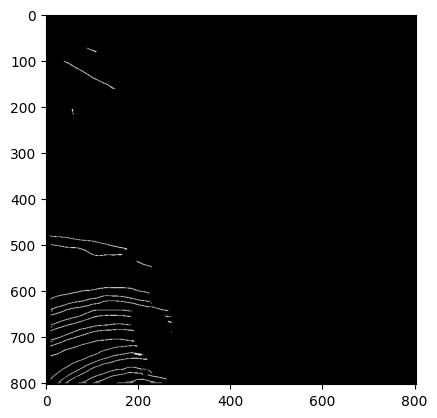

In [7]:
plt.imshow(tomo_skel[:,:, 50], cmap='gray');

In [12]:
target_path = get_save_path(target_dir, Path(path_).stem)
print("saving  skeleton to :", target_path)
nrrd.write(target_path, tomo_skel.astype(np.uint8))

saving  skeleton to : /mnt/big_data/rseghiri/skeletons/chlamy_processed_gt/2917_tomo.nrrd


In [49]:
tomo_path.stem

'tomo_000'

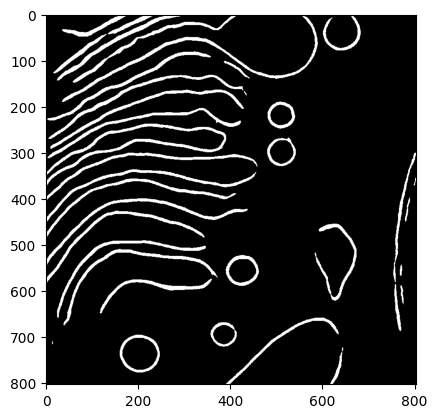

In [42]:
plt.imshow(tomo[:,:, 50], cmap='gray');

In [9]:
def get_save_path(target_dir: Path, stem: str):
    tomo_nbr = stem.split('_')[0]
    return str(Path(target_dir) / f"{tomo_nbr}_tomo.nrrd")

target_dir = Path('/mnt/big_data/rseghiri/skeletons/chlamy_processed_gt')


In [8]:
all_tomos = [Path('/mnt/big_data/rseghiri/chlamy_processed_gt/0298_membrane_cropped_z_55_449_v_size_10.nrrd')]
for path_ in all_tomos:
    print("processing: ", path_)
    tomo, _ = nrrd.read(path_)
    print("prepping")
    tomo_dsts = prepare_input(tomo).astype(np.float32)
    tomo_dsts = tomo_dsts.clip(0)
    print("getting skel")
    tomo_skel = surface_skel(tomo_dsts, f=0)
    tomo_skel = tomo_skel * tomo # get rid of noises
    target_path = get_save_path(target_dir, path_.stem)
    print("saving  skeleton to :", target_path)
    nrrd.write(target_path, tomo_skel.astype(np.uint8))
    
    

processing:  /mnt/big_data/rseghiri/chlamy_processed_gt/0298_membrane_cropped_z_55_449_v_size_10.nrrd
prepping


/tmp/ipykernel_1172075/613479029.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  tomo_dsts = prepare_input(tomo).astype(np.float32)


getting skel


NameError: name 'get_save_path' is not defined

In [10]:
target_path = get_save_path(target_dir, path_.stem)
print("saving  skeleton to :", target_path)
nrrd.write(target_path, tomo_skel.astype(np.uint8))

saving  skeleton to : /mnt/big_data/rseghiri/skeletons/chlamy_processed_gt/0298_tomo.nrrd


In [61]:
nrrd.write??

Signature:
nrrd.write(
    file: Union[str, IO],
    data: numpy.ndarray[tuple[int, ...], numpy.dtype[+_ScalarType_co]],
    header: Optional[Dict[str, Any]] = None,
    detached_header: bool = False,
    relative_data_path: bool = True,
    custom_field_map: Optional[Dict[str, Literal['int', 'double', 'string', 'int list', 'double list', 'string list', 'quoted string list', 'int vector', 'double vector', 'int matrix', 'double matrix']]] = None,
    compression_level: int = 9,
    index_order: Literal['F', 'C'] = 'F',
)
Source:   
def write(file: Union[str, IO], data: npt.NDArray, header: Optional[NRRDHeader] = None,
          detached_header: bool = False, relative_data_path: bool = True,
          custom_field_map: Optional[NRRDFieldMap] = None, compression_level: int = 9, index_order: IndexOrder = 'F'):
    """Write :class:`numpy.ndarray` to NRRD file

    The :obj:`file` parameter specifies the absolute or relative filename to write the NRRD file to or an
    io.BytesIO object.

  

In [58]:
get_save_path(target_dir, '0050')

'/mnt/big_data/rseghiri/skeletons/chlamy_processed_gt/0050_tomo.nrrd'

In [57]:
ls /mnt/big_data/rseghiri/skeletons/chlamy_processed_gt